##### Setup

###### 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

###### 2.

In [2]:
def exibir_controles(funcao, controles):
    # interactive_output executa com os defaults e observa alterações posteriores.
    saida = widgets.interactive_output(funcao, controles)
    display(widgets.VBox(list(controles.values())), saida)
    return saida


def finalizar_figura(figura, arquivo):
    figura.tight_layout()
    figura.savefig(arquivo, dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(figura)


def deslizador(valor, minimo, maximo, passo, descricao):
    return widgets.FloatSlider(value=valor, min=minimo, max=maximo, step=passo,
                               description=descricao, continuous_update=False)

###### 3.

In [3]:
def normalizar(vetores):
    dados = np.asarray(vetores, dtype=float)
    norma = np.linalg.norm(dados, axis=-1, keepdims=True)
    if not np.all(np.isfinite(dados)) or np.any(norma < 1e-12):
        raise ValueError('Direções e normais precisam ser finitas e não nulas')
    return dados/norma


def componentes_phong(normais, luz, observador, ka, kd, ks, expoente, ia, id_, is_):
    """Aceita vetores individuais ou campos de vetores e luz escalar ou RGB."""
    n, l, v = normalizar(normais), normalizar(luz), normalizar(observador)
    nl = np.sum(n*l, axis=-1, keepdims=True)
    reflexao = 2*nl*n-l
    rv = np.maximum(np.sum(v*reflexao, axis=-1, keepdims=True), 0)
    ambiente = np.broadcast_to(ka*np.asarray(ia), np.broadcast_shapes(nl.shape, np.shape(ia)))
    difusa = kd*np.asarray(id_)*np.maximum(nl, 0)
    # Luz atrás da superfície não produz brilho especular.
    especular = ks*np.asarray(is_)*np.where(nl > 0, rv**expoente, 0)
    return ambiente, difusa, especular

##### QUESTÃO1

###### 1.

In [4]:
# A superfície original é plana: direções e normal são constantes em toda a grade.
eixo_grade_q1 = np.linspace(-1, 1, 50)
x_q1, y_q1 = np.meshgrid(eixo_grade_q1, eixo_grade_q1)
normais_q1 = np.zeros((*x_q1.shape, 3))
normais_q1[..., 2] = 1
controles_q1 = {
    'ka': deslizador(0.5, 0, 1, 0.05, 'ka'),
    'kd': deslizador(0.7, 0, 1, 0.05, 'kd'),
    'ks': deslizador(0.9, 0, 1, 0.05, 'ks'),
    'expoente': widgets.IntSlider(value=20, min=1, max=100, description='Shininess', continuous_update=False),
    'ia': deslizador(0.1, 0, 1, 0.05, 'Ia'),
    'id_': deslizador(0.7, 0, 1, 0.05, 'Id'),
    'is_': deslizador(0.5, 0, 1, 0.05, 'Is'),
    'luz_x': deslizador(1, -2, 2, 0.1, 'Luz x'),
    'luz_y': deslizador(1, -2, 2, 0.1, 'Luz y'),
    'luz_z': deslizador(1, -2, 2, 0.1, 'Luz z'),
    'vista_x': deslizador(0, -2, 2, 0.1, 'Vista x'),
    'vista_y': deslizador(0, -2, 2, 0.1, 'Vista y'),
    'vista_z': deslizador(1, -2, 2, 0.1, 'Vista z'),
}

###### 2.

Intensidades: ambiente=0.05000, difusa=0.28290, especular=0.00001, total=0.33291


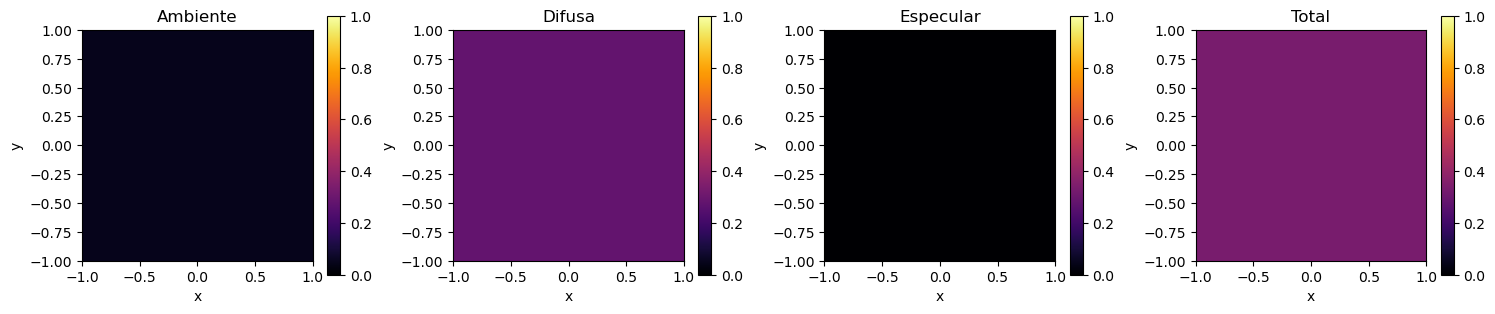

In [5]:
def calcular_superficie_q1(ka, kd, ks, expoente, ia, id_, is_, luz_x, luz_y, luz_z, vista_x, vista_y, vista_z):
    return componentes_phong(normais_q1, [luz_x, luz_y, luz_z],
        [vista_x, vista_y, vista_z], ka, kd, ks, expoente, ia, id_, is_)


def mostrar_componentes_q1(**valores):
    try:
        ambiente, difusa, especular = calcular_superficie_q1(**valores)
    except ValueError as erro:
        print(erro)
        return
    componentes = [ambiente[..., 0], difusa[..., 0], especular[..., 0]]
    total = sum(componentes)
    figura, eixos = plt.subplots(1, 4, figsize=(15, 4))
    # A mesma escala permite comparar componentes sem normalizar cada imagem.
    limite = max(1, float(total.max()))
    for eixo, dados, titulo in zip(eixos, componentes+[total], ['Ambiente', 'Difusa', 'Especular', 'Total']):
        imagem = eixo.imshow(dados, cmap='inferno', origin='lower', extent=(-1, 1, -1, 1), vmin=0, vmax=limite)
        eixo.set(title=titulo, xlabel='x', ylabel='y')
        figura.colorbar(imagem, ax=eixo, shrink=0.7)
    print('Intensidades:', ', '.join(f'{nome}={dados[0,0]:.5f}' for nome, dados in zip(['ambiente', 'difusa', 'especular', 'total'], componentes+[total])))
    finalizar_figura(figura, 'lista6_questao1_componentes.png')


mostrar_componentes_q1(**{nome: controle.value for nome, controle in controles_q1.items()})

###### 3.

In [6]:
# A iluminação permanece espacialmente uniforme no plano original.
# Shininess altera o valor do brilho; variar a direção da luz muda N·L e R·V.
saida_phong_q1 = exibir_controles(mostrar_componentes_q1, controles_q1)

Output()

##### QUESTÃO2

###### 1.

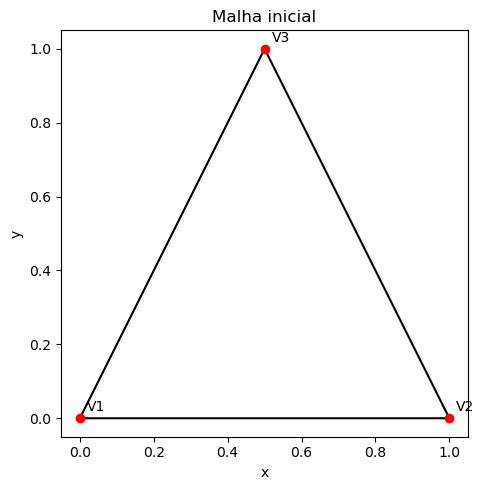

In [7]:
def iluminacao_phong(normais, luz, observador, ka, kd, ks, expoente, ia, id_, is_):
    return sum(componentes_phong(normais, luz, observador, ka, kd, ks, expoente, ia, id_, is_))

from io import BytesIO
from PIL import Image


POLIGONOS_Q2 = {
    'Triângulo': np.array([[0, 0, 0], [1, 0, 0], [0.5, 1, 0]], dtype=float),
    'Quadrilátero': np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0]], dtype=float),
    'Pentágono': np.column_stack((0.5+0.48*np.cos(np.linspace(0, 2*np.pi, 5, endpoint=False)+np.pi/2),
                                 0.5+0.48*np.sin(np.linspace(0, 2*np.pi, 5, endpoint=False)+np.pi/2), np.zeros(5))),
}


def construir_malha_q2(poligono, variacao):
    vertices = POLIGONOS_Q2[poligono].copy()
    # Todos os polígonos são convexos e aceitam triangulação em leque.
    faces = np.array([[0, i, i+1] for i in range(1, len(vertices)-1)])
    normais = np.column_stack((variacao*(vertices[:, :2]-vertices[:, :2].mean(axis=0)), np.ones(len(vertices))))
    return vertices, faces, normalizar(normais)


controles_q2 = {
    'poligono': widgets.Dropdown(options=list(POLIGONOS_Q2), value='Triângulo', description='Polígono'),
    'variacao': deslizador(0, 0, 3, 0.1, 'Normais'),
    'ka': deslizador(0.2, 0, 1, 0.05, 'ka'),
    'kd': deslizador(0.7, 0, 1, 0.05, 'kd'),
    'ks': deslizador(0.5, 0, 1, 0.05, 'ks'),
    'expoente': widgets.IntSlider(value=10, min=1, max=100, description='Expoente', continuous_update=False),
    'luz_x': deslizador(0.5, -2, 2, 0.1, 'Luz x'),
    'luz_y': deslizador(0.5, -2, 2, 0.1, 'Luz y'),
    'luz_z': deslizador(1, -2, 2, 0.1, 'Luz z'),
    'vista_x': deslizador(0, -2, 2, 0.1, 'Vista x'),
    'vista_y': deslizador(0, -2, 2, 0.1, 'Vista y'),
    'vista_z': deslizador(1, -2, 2, 0.1, 'Vista z'),
}


vertices_q2, faces_q2, normais_q2 = construir_malha_q2('Triângulo', 0)
figura, eixo = plt.subplots(figsize=(5, 5))
eixo.triplot(vertices_q2[:, 0], vertices_q2[:, 1], faces_q2, color='black')
eixo.scatter(*vertices_q2[:, :2].T, color='red')
for i, vertice in enumerate(vertices_q2):
    eixo.annotate(f'V{i+1}', vertice[:2], xytext=(5, 5), textcoords='offset points')
eixo.set(title='Malha inicial', aspect='equal', xlabel='x', ylabel='y')
finalizar_figura(figura, 'lista6_questao2_malha.png')

###### 2.

Diferença média antes de limitar RGB: 0.000000


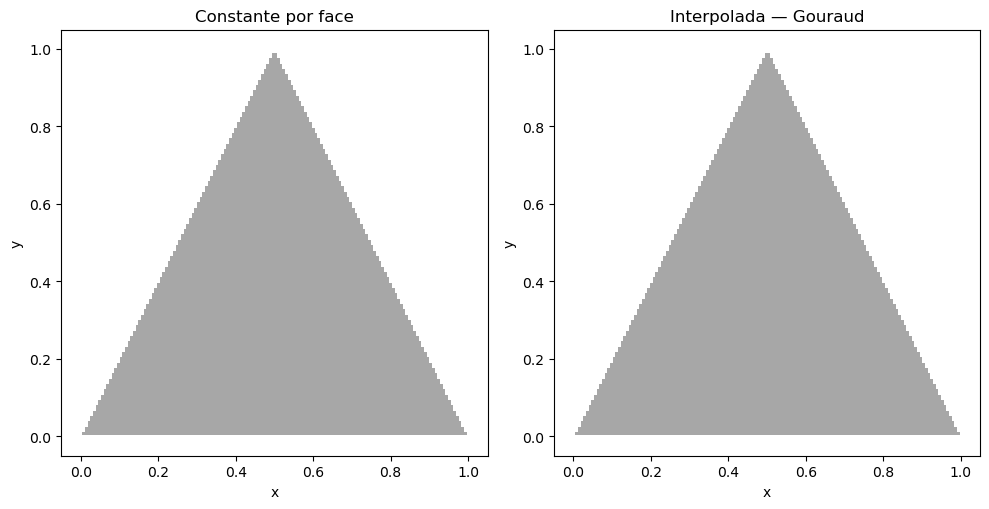

In [8]:
def rasterizar_malha(vertices, faces, normais, luz, vista, ka, kd, ks, expoente, resolucao=160):
    cores_vertices = iluminacao_phong(normais, luz, vista, ka, kd, ks, expoente,
                                      np.full(3, 0.1), np.ones(3), np.ones(3))
    xy = vertices[:, :2]
    minimo, maximo = xy.min(axis=0)-0.05, xy.max(axis=0)+0.05
    x, y = np.meshgrid(np.linspace(minimo[0], maximo[0], resolucao),
                       np.linspace(minimo[1], maximo[1], resolucao))
    pontos = np.stack((x, y), axis=-1)
    constante = np.zeros((*x.shape, 3))
    interpolada = np.zeros_like(constante)
    mascara = np.zeros(x.shape, dtype=bool)
    for face in faces:
        a, b, c = xy[face]
        matriz = np.column_stack((b-a, c-a))
        uv = (pontos-a) @ np.linalg.inv(matriz).T
        pesos = np.concatenate((1-uv.sum(axis=-1, keepdims=True), uv), axis=-1)
        dentro = np.all(pesos >= -1e-10, axis=-1)
        # Flat: uma iluminação no centro da face e normal média, sem interpolação.
        normal_face = normalizar(normais[face].mean(axis=0))
        cor_face = iluminacao_phong(normal_face, luz, vista, ka, kd, ks, expoente,
                                    np.full(3, 0.1), np.ones(3), np.ones(3))
        constante[dentro] = cor_face
        interpolada[dentro] = pesos[dentro] @ cores_vertices[face]
        mascara |= dentro
    # UV acompanha a caixa do polígono, independente da margem do gráfico.
    uv_textura = (pontos-xy.min(axis=0))/np.ptp(xy, axis=0)
    extensao = (minimo[0], maximo[0], minimo[1], maximo[1])
    return constante, interpolada, mascara, uv_textura, extensao


def calcular_tonalizacao_q2(poligono, variacao, ka, kd, ks, expoente, luz_x, luz_y, luz_z, vista_x, vista_y, vista_z):
    vertices, faces, normais = construir_malha_q2(poligono, variacao)
    return rasterizar_malha(vertices, faces, normais, [luz_x, luz_y, luz_z],
                            [vista_x, vista_y, vista_z], ka, kd, ks, expoente)


def exibir_tonalizacoes_q2(constante, interpolada, mascara, extensao, arquivo):
    figura, eixos = plt.subplots(1, 2, figsize=(10, 5))
    for eixo, dados, titulo in zip(eixos, [constante, interpolada], ['Constante por face', 'Interpolada — Gouraud']):
        rgba = np.dstack((np.clip(dados, 0, 1), mascara.astype(float)))
        eixo.imshow(rgba, origin='lower', extent=extensao, interpolation='nearest')
        eixo.set(title=titulo, aspect='equal', xlabel='x', ylabel='y')
    finalizar_figura(figura, arquivo)


def mostrar_tonalizacao_q2(**valores):
    try:
        constante, interpolada, mascara, uv, extensao = calcular_tonalizacao_q2(**valores)
    except ValueError as erro:
        print(erro)
        return
    diferenca = np.abs(constante[mascara]-interpolada[mascara]).mean()
    print(f'Diferença média antes de limitar RGB: {diferenca:.6f}')
    exibir_tonalizacoes_q2(constante, interpolada, mascara, extensao, 'lista6_questao2_tonalizacao.png')


mostrar_tonalizacao_q2(**{nome: controle.value for nome, controle in controles_q2.items()})

###### 3.

In [9]:
# Normais=0 reproduz o PDF; aumentar a variação revela a interpolação.
# Gouraud interpola iluminação dos vértices, em vez de recalcular Phong por pixel.
saida_tonalizacao_q2 = exibir_controles(mostrar_tonalizacao_q2, controles_q2)

Output()

###### 4.

In [10]:
# A textura inicial é gerada em memória, sem downloads ou arquivos externos.
def textura_tabuleiro(tamanho=128):
    y, x = np.indices((tamanho, tamanho))
    alternancia = ((x//16+y//16)%2)[..., None]
    return np.where(alternancia, np.array([0.85, 0.35, 0.12]), np.array([0.95, 0.9, 0.7]))


textura_enviada_q2 = None
upload_q2 = widgets.FileUpload(accept='image/*', multiple=False, description='Enviar textura')
fonte_textura_q2 = widgets.Dropdown(options=['Tabuleiro', 'Imagem enviada'], value='Tabuleiro', description='Textura')


def carregar_textura_q2(mudanca):
    global textura_enviada_q2
    if not upload_q2.value:
        return
    # ipywidgets 7 usa um dicionário; ipywidgets 8 usa uma sequência.
    enviados = upload_q2.value
    arquivo = next(iter(enviados.values())) if isinstance(enviados, dict) else enviados[0]
    try:
        with Image.open(BytesIO(bytes(arquivo['content']))) as imagem:
            imagem = imagem.convert('RGB')
            imagem.thumbnail((512, 512))
            textura_enviada_q2 = np.asarray(imagem, dtype=float)/255
    except (OSError, ValueError) as erro:
        print(f'Não foi possível ler a textura: {erro}')
        return
    # A seleção e a notificação também atualizam uma segunda imagem enviada.
    fonte_textura_q2.value = 'Imagem enviada'
    fonte_textura_q2.notify_change({'name': 'value', 'type': 'change',
        'old': fonte_textura_q2.value, 'new': fonte_textura_q2.value, 'owner': fonte_textura_q2})


upload_q2.observe(carregar_textura_q2, names='value')
display(upload_q2)


def amostrar_textura_q2(textura, uv, escala):
    coordenadas = np.mod(uv*escala, 1.0)
    altura, largura = textura.shape[:2]
    x = np.minimum((coordenadas[..., 0]*largura).astype(int), largura-1)
    y = np.minimum(((1-coordenadas[..., 1])*altura).astype(int), altura-1)
    return textura[y, x]


def mostrar_textura_q2(fonte, escala, influencia, **valores):
    try:
        constante, interpolada, mascara, uv, extensao = calcular_tonalizacao_q2(**valores)
    except ValueError as erro:
        print(erro)
        return
    if fonte == 'Imagem enviada' and textura_enviada_q2 is None:
        print('Envie uma imagem ou selecione Tabuleiro.')
        return
    textura = textura_tabuleiro() if fonte == 'Tabuleiro' else textura_enviada_q2
    material = (1-influencia) + influencia*amostrar_textura_q2(textura, uv, escala)
    # Modelo didático: a textura modula a intensidade local dos dois métodos.
    exibir_tonalizacoes_q2(constante*material, interpolada*material, mascara,
                           extensao, 'lista6_questao2_textura.png')


controles_textura_q2 = dict(controles_q2, fonte=fonte_textura_q2,
    escala=deslizador(1, 0.25, 8, 0.25, 'Escala UV'),
    influencia=deslizador(1, 0, 1, 0.05, 'Influência'))
saida_textura_q2 = exibir_controles(mostrar_textura_q2, controles_textura_q2)

FileUpload(value=(), accept='image/*', description='Enviar textura')

Output()